# 04 - Classical Baselines Benchmark (FIFO, SJF, Priority, Best-Fit)

This notebook evaluates the 4 classical heuristic schedulers across the 6 standard benchmark scenarios using fixed evaluation seeds:
- **FIFO**: First-In First-Out
- **SJF**: Shortest Job First
- **Priority**: User Priority with FIFO Tie-breaking
- **Best-Fit**: Resource Fragmentation Minimization

In [1]:
import sys
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Ensure project root is in python path
sys.path.insert(0, os.path.abspath('..'))

from baselines.fifo import FIFOScheduler
from baselines.sjf import SJFScheduler
from baselines.priority import PriorityScheduler
from baselines.best_fit import BestFitScheduler
from evaluation.evaluator import Evaluator
from evaluation.reports import generate_comparison_dataframe
from workloads.scenarios import list_scenarios

print("Baselines and Evaluator imported successfully!")

Baselines and Evaluator imported successfully!


## 1. Run Evaluation Benchmark

In [2]:
eval_seeds = [101, 202, 303]
scenarios = list_scenarios()
schedulers = [FIFOScheduler(), SJFScheduler(), PriorityScheduler(), BestFitScheduler()]

evaluator = Evaluator(cluster_config_path="../configs/cluster_small.yaml", horizon_seconds=1800.0)

all_results = {}
for s in schedulers:
    print(f"Evaluating {s.name}...")
    all_results[s.name] = evaluator.evaluate_scheduler(s, scenarios=scenarios, seeds=eval_seeds)

print("\nAll baseline evaluations complete!")

Evaluating FIFO...
Evaluating SJF...
Evaluating Priority...
Evaluating BestFit...

All baseline evaluations complete!


## 2. Benchmark Comparison Tables

In [3]:
for sc in scenarios:
    df_sc = generate_comparison_dataframe(all_results, scenario_name=sc)
    print(f"\n{'='*55}")
    print(f"Scenario: {sc.upper()}")
    print(f"{'='*55}")
    print(df_sc.to_string(index=False))


Scenario: BALANCED
                Metric   FIFO    SJF Priority BestFit
          Mean JCT (s) 237.33 245.93   243.40  276.01
           P95 JCT (s) 654.27 849.45   801.01  659.72
   Mean Queue Wait (s) 119.11 120.31   119.26  154.89
   GPU Utilization (%) 49.83% 65.41%   66.01%  59.25%
  Throughput (jobs/hr)  68.67  79.33    78.67   80.67
Deadline Violation (%) 32.68% 22.68%   23.51%  37.18%
        Completed Jobs     34     39       39      40
     Cumulative Reward  32.30  49.34    47.63   32.61

Scenario: TRAINING_HEAVY
                Metric    FIFO     SJF Priority BestFit
          Mean JCT (s)  757.08  627.29   730.90  788.37
           P95 JCT (s) 1227.77 1035.10  1209.64 1177.55
   Mean Queue Wait (s)  405.53  299.34   399.47  433.18
   GPU Utilization (%)  42.90%  38.65%   44.83%  46.61%
  Throughput (jobs/hr)   12.00   11.33    11.33    8.67
Deadline Violation (%)  43.33%  42.22%   47.62%  41.67%
        Completed Jobs       6       5        5       4
     Cumulative Rewa

## 3. Comparative Metric Plots (Balanced Scenario)

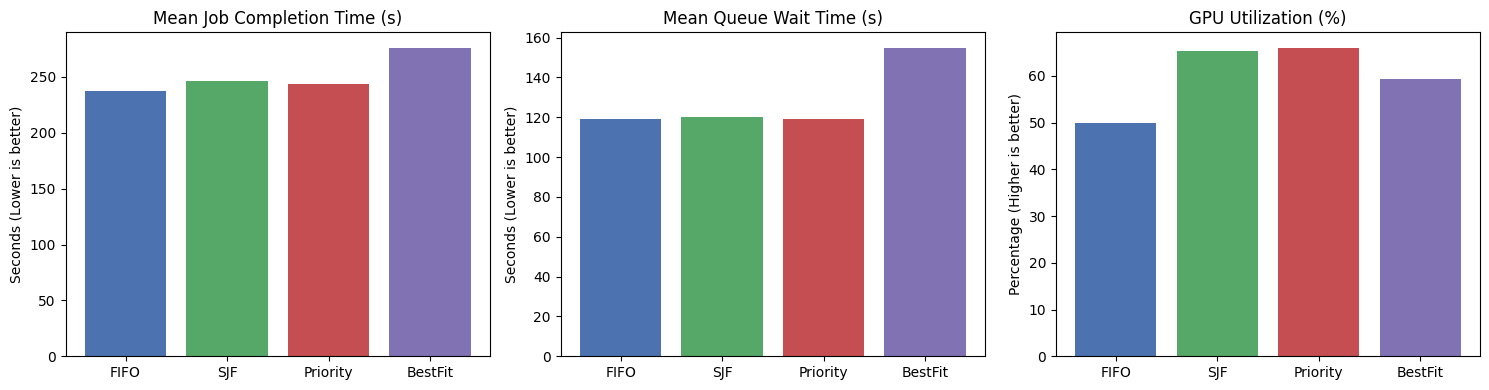

In [4]:
policies = [s.name for s in schedulers]
jcts = [all_results[p]["balanced"]["summary"]["mean_jct"]["mean"] for p in policies]
waits = [all_results[p]["balanced"]["summary"]["mean_wait_time"]["mean"] for p in policies]
utils = [all_results[p]["balanced"]["summary"]["gpu_utilization"]["mean"] * 100 for p in policies]

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 4))

ax1.bar(policies, jcts, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
ax1.set_title("Mean Job Completion Time (s)")
ax1.set_ylabel("Seconds (Lower is better)")

ax2.bar(policies, waits, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
ax2.set_title("Mean Queue Wait Time (s)")
ax2.set_ylabel("Seconds (Lower is better)")

ax3.bar(policies, utils, color=['#4C72B0', '#55A868', '#C44E52', '#8172B3'])
ax3.set_title("GPU Utilization (%)")
ax3.set_ylabel("Percentage (Higher is better)")

plt.tight_layout()
plt.show()